In [ ]:
import ee
import geemap
import math
import pandas as pd

In [ ]:
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='ee-cydata') # <- cambiar a su proyecto de GEE debe estar registrado en GEE

print("Entorno de Google Earth Engine configurado y autenticado correctamente.")


Entorno de Google Earth Engine configurado y autenticado correctamente.


In [ ]:
punto_lat = 18.18
punto_lon = -71.17
punto_anzuelo = ee.Geometry.Point([punto_lon, punto_lat])


cuenca_vector = ee.FeatureCollection("WWF/HydroSHEDS/v1/Basins/hybas_12") \
                  .filterBounds(punto_anzuelo) \
                  .first()

# 4. Importe y recorte del DEM (SRTM)
dem = ee.Image("USGS/SRTMGL1_003")
dem_cuenca = dem.clip(cuenca_vector.geometry())

# Visualización en geemap
Map = geemap.Map()
Map.centerObject(cuenca_vector, 10)
Map.addLayer(cuenca_vector, {}, 'Cuenca (HydroBASINS L12)')
Map.addLayer(dem_cuenca, {'min': 0, 'max': 3000}, 'DEM de la Cuenca')
Map

Map(center=[18.237118274896538, -71.15607026274627], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Cargar la colección de CHIRPS (1981 - presente)
fecha_inicio = '1981-01-01'
fecha_fin = '2025-12-31'

# Cargar la colección de CHIRPS (1981 - presente)
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
           .filterDate(fecha_inicio,fecha_fin) \
           .select('precipitation')

In [ ]:
print(f"Número de imágenes en la colección CHIRPS: {chirps.size().getInfo()} dias Equivalente a {round(chirps.size().getInfo()/365)} años")

Número de imágenes en la colección CHIRPS: 16435 dias Equivalente a 45 años


In [ ]:
print("Propiedades de la primera imagen en la colección CHIRPS:")
chirps.first().getInfo()

Propiedades de la primera imagen en la colección CHIRPS:


{'type': 'Image',
 'bands': [{'id': 'precipitation',
   'data_type': {'type': 'PixelType', 'precision': 'float'},
   'dimensions': [7200, 2000],
   'crs': 'EPSG:4326',
   'crs_transform': [0.05, 0, -180, 0, -0.05, 50]}],
 'version': 1747259052830646,
 'id': 'UCSB-CHG/CHIRPS/DAILY/19810101',
 'properties': {'system:time_start': 347155200000,
  'system:footprint': {'type': 'LinearRing',
   'coordinates': [[-180, -90],
    [180, -90],
    [180, 90],
    [-180, 90],
    [-180, -90]]},
  'system:time_end': 347241600000,
  'system:asset_size': 4194949,
  'system:index': '19810101'}}

In [ ]:
print('\nValor del pixel de precipitación en el punto_anzuelo (primera imagen de CHIRPS):')
first_chirps_image = chirps.first()

pixel_value_chirps = first_chirps_image.reduceRegion(
    reducer=ee.Reducer.first(),
    geometry=punto_anzuelo,
    scale=5566 # Escala nativa de CHIRPS, aproximadamente 5.5 km
).get('precipitation').getInfo()
display(pixel_value_chirps)


Valor del pixel de precipitación en el punto_anzuelo (primera imagen de CHIRPS):


0

In [ ]:
print('\nValor del pixel del DEM en el punto_anzuelo:')
pixel_value = dem_cuenca.reduceRegion(
    reducer=ee.Reducer.first(),
    geometry=punto_anzuelo,
    scale=30 # La escala del DEM es 30 metros
).get('elevation').getInfo()
display(pixel_value)


Valor del pixel del DEM en el punto_anzuelo:


435

In [ ]:
fecha_ejemplo = '1998-09-22'


In [ ]:
# Cargar la colección completa y filtrar el día exacto
imagen_lluvia_dia = chirps.filterDate(fecha_ejemplo).first()

# Recortar la imagen satelital para los límites de nuestra cuenca
lluvia_cuenca = imagen_lluvia_dia.clip(cuenca_vector.geometry())

# Configurar una paleta de colores atractiva para la precipitación (Azules)
paleta_lluvia = {
    'min': 0,
    'max': 20,
    'palette': ['blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

# Añadir las capas al mapa interactivo existente
Map.addLayer(lluvia_cuenca, paleta_lluvia, f'Lluvia el {fecha_ejemplo} (mm)')

# Mostrar el mapa actualizado en Colab
Map

Map(bottom=235408.0, center=[18.24761153423444, -71.03553771972658], controls=(WidgetControl(options=['positio…

In [ ]:


# defino la función promedio arial de cada imagen
def calcular_promedio_cuenca(image):
    media = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=cuenca_vector.geometry(),
        scale=5566, # CHIRPS native resolution (~5.5 km per pixel)
        maxPixels=1e9
    )
    # Return a Feature (row) with the date and the average precipitation value
    return ee.Feature(None, {
        'timestamp_ms': image.get('system:time_start'), # Extract timestamp directly
        'lluvia_mm': media.get('precipitation')
    })

chirps_historico = chirps

# Apply the function to the entire historical collection in a massive way
feat_collection = ee.FeatureCollection(chirps_historico.map(calcular_promedio_cuenca))
## esto ya un valor promedio ya no es una imagen

#extraer como datos
list_data = geemap.ee_to_df(feat_collection) ## df-> pandas dataframe

# Convert and clean the DataFrame in Pandas
df = pd.DataFrame(list_data)
df

,lluvia_mm,timestamp_ms
0,0.405516,347155200000
1,9.472256,347241600000
2,2.567490,347328000000
3,0.000000,347414400000
4,0.000000,347500800000
...,...,...
16430,0.000000,1766707200000
16431,0.000000,1766793600000
16432,0.000000,1766880000000
16433,0.000000,1766966400000


In [ ]:
# Convert timestamp to datetime
df['fecha'] = pd.to_datetime(df['timestamp_ms'], unit='ms') # Convert timestamp directly
df['lluvia_mm'] = pd.to_numeric(df['lluvia_mm'])
# Drop the original timestamp_ms column as 'fecha' is now the correct datetime column
df = df.drop(columns=['timestamp_ms'])
df = df.dropna().sort_values('fecha').reset_index(drop=True)

In [ ]:
df

,lluvia_mm,fecha
0,0.405516,1981-01-01
1,9.472256,1981-01-02
2,2.567490,1981-01-03
3,0.000000,1981-01-04
4,0.000000,1981-01-05
...,...,...
16430,0.000000,2025-12-26
16431,0.000000,2025-12-27
16432,0.000000,2025-12-28
16433,0.000000,2025-12-29


In [ ]:
df.to_csv('serie_lluvia_cuenca.csv')

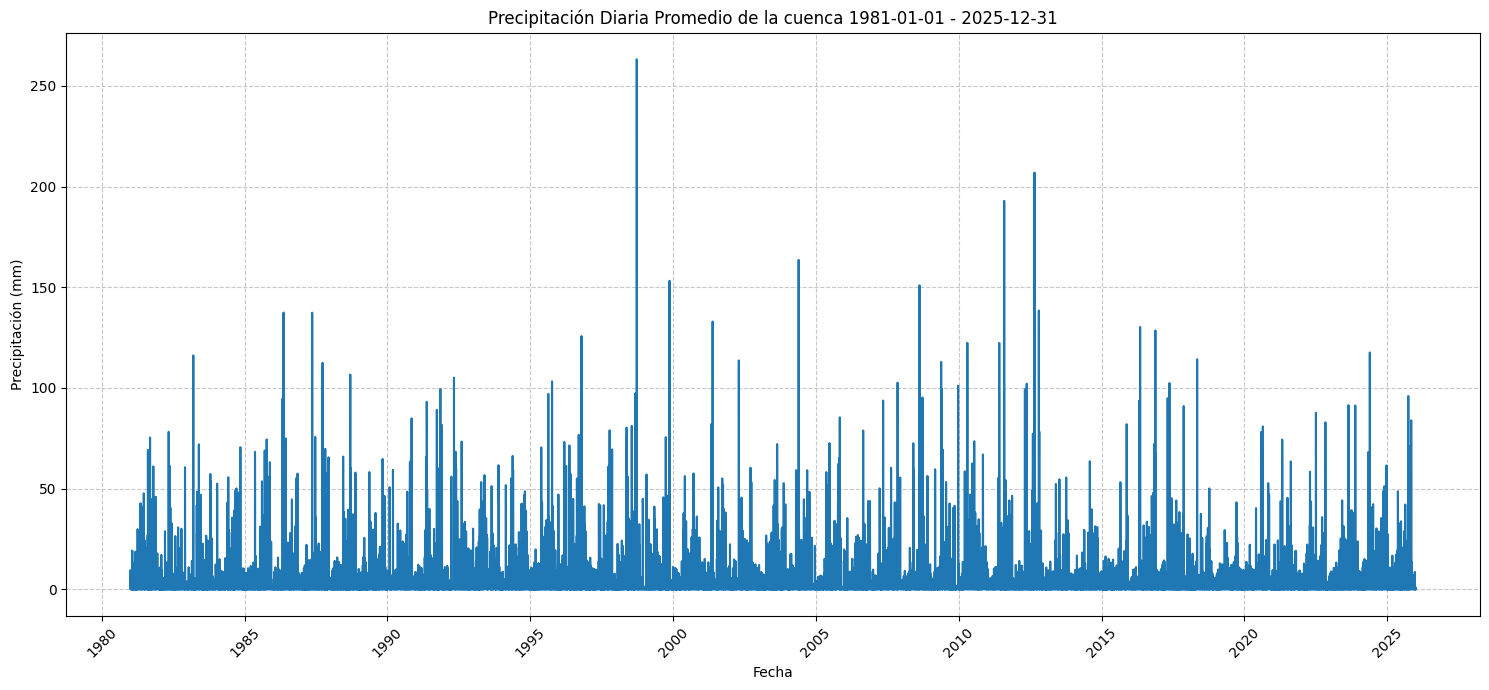

In [ ]:
#datos en df ahora los vamos a ver como serie de tiempo
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar la serie de tiempo histórica con los datos corregidos
fig = plt.figure(figsize=(15, 7))
sns.lineplot(x='fecha', y='lluvia_mm', data=df)
plt.title('Precipitación Diaria Promedio de la cuenca ' + fecha_inicio+' - '+fecha_fin)
plt.xlabel('Fecha')
plt.ylabel('Precipitación (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#por sanidad siempre es bueno limpiar los datos

In [ ]:
print("Datos en crudo (list_data):")
display(list_data.head())
display(list_data.tail())

Datos en crudo (list_data):


,lluvia_mm,timestamp_ms
0,0.405516,347155200000
1,9.472256,347241600000
2,2.567490,347328000000
3,0.000000,347414400000
4,0.000000,347500800000


,lluvia_mm,timestamp_ms
16430,0.0,1766707200000
16431,0.0,1766793600000
16432,0.0,1766880000000
16433,0.0,1766966400000
16434,0.0,1767052800000


In [ ]:
# Extraer año y mes de la columna 'fecha'
df['year'] = df['fecha'].dt.year
df['month'] = df['fecha'].dt.month

# Definir un día de lluvia como precipitación > 0
df['is_rainy'] = df['lluvia_mm'] >= 1

# Calcular días de lluvia por mes
monthly_rainy_days = df.groupby(['year', 'month'])['is_rainy'].sum().reset_index()
monthly_rainy_days['is_rainy'] = monthly_rainy_days['is_rainy'].astype(int)
print("Días de Lluvia por Mes (ejemplo de los primeros y últimos registros):")
display(monthly_rainy_days.head())
display(monthly_rainy_days.tail())

# Calcular precipitación promedio mensual
monthly_avg_prec = df.groupby(['year', 'month'])['lluvia_mm'].mean().reset_index()
print("\nPrecipitación Promedio Mensual (ejemplo de los primeros y últimos registros):")
display(monthly_avg_prec.head())
display(monthly_avg_prec.tail())

Días de Lluvia por Mes (ejemplo de los primeros y últimos registros):


,year,month,is_rainy
0,1981,1,9
1,1981,2,10
2,1981,3,11
3,1981,4,3
4,1981,5,15


,year,month,is_rainy
535,2025,8,10
536,2025,9,14
537,2025,10,20
538,2025,11,12
539,2025,12,5



Precipitación Promedio Mensual (ejemplo de los primeros y últimos registros):


,year,month,lluvia_mm
0,1981,1,1.831494
1,1981,2,1.572638
2,1981,3,2.229875
3,1981,4,1.550902
4,1981,5,10.093521


,year,month,lluvia_mm
535,2025,8,4.859073
536,2025,9,8.202742
537,2025,10,17.034817
538,2025,11,4.756631
539,2025,12,0.701555


In [ ]:
#calcular la cantidad de dias lluviosos por mes de 2005
df[df['year'] == 2005].groupby(['year', 'month'])['is_rainy'].sum().reset_index()

,year,month,is_rainy
0,2005,1,5
1,2005,2,5
2,2005,3,6
3,2005,4,12
4,2005,5,17
5,2005,6,16
6,2005,7,13
7,2005,8,17
8,2005,9,12
9,2005,10,21


<Axes: title={'center': 'Dias de lluvia por mes'}, xlabel='month'>

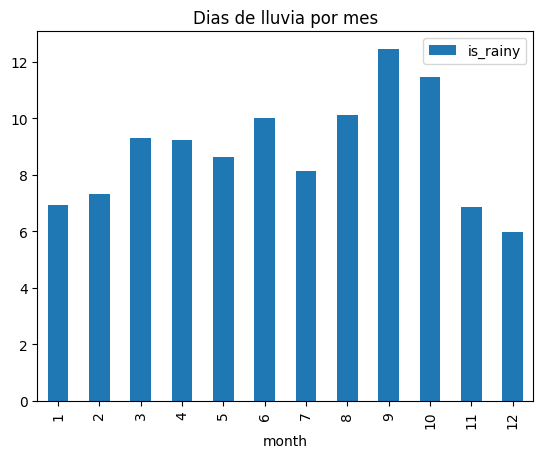

In [ ]:
#calcular el promedio de dias lluviosos de por mes de toda la serie, deberían ser 12 filas
df_dias=df.groupby(['year', 'month'])['is_rainy'].sum().reset_index()
dias_lluvia=df_dias.groupby('month')['is_rainy'].mean().reset_index()
#plotear is_rainy de dias_lluvia como barras
dias_lluvia.plot(x='month', y='is_rainy', kind='bar',title='Dias de lluvia por mes')

In [ ]:
# Calcular días consecutivos de lluvia
df['rain_block'] = (df['is_rainy'] != df['is_rainy'].shift()).cumsum()
consecutive_rainy_periods = df[df['is_rainy']].groupby(['year', 'month', 'rain_block']).size().reset_index(name='consecutive_rain_days')

print("Promedio y Máximo de Días Consecutivos Lluviosos por Mes:")
monthly_consecutive_rain_stats = consecutive_rainy_periods.groupby(['year', 'month'])['consecutive_rain_days'].agg(['mean', 'max']).reset_index()
display(monthly_consecutive_rain_stats.head())
display(monthly_consecutive_rain_stats.tail())

# Calcular días consecutivos secos
df['dry_block'] = (df['is_rainy'] == df['is_rainy'].shift()).cumsum()
consecutive_dry_periods = df[~df['is_rainy']].groupby(['year', 'month', 'dry_block']).size().reset_index(name='consecutive_dry_days')

print("\nPromedio y Máximo de Días Consecutivos Secos por Mes:")
monthly_consecutive_dry_stats = consecutive_dry_periods.groupby(['year', 'month'])['consecutive_dry_days'].agg(['mean', 'max']).reset_index()
display(monthly_consecutive_dry_stats.head())
display(monthly_consecutive_dry_stats.tail())

Promedio y Máximo de Días Consecutivos Lluviosos por Mes:


,year,month,mean,max
0,1981,1,1.500000,2
1,1981,2,1.666667,3
2,1981,3,1.833333,2
3,1981,4,1.500000,2
4,1981,5,3.750000,6


,year,month,mean,max
535,2025,8,1.666667,3
536,2025,9,2.333333,4
537,2025,10,3.333333,6
538,2025,11,3.000000,6
539,2025,12,1.000000,1



Promedio y Máximo de Días Consecutivos Secos por Mes:


,year,month,mean,max
0,1981,1,1.157895,2
1,1981,2,1.200000,2
2,1981,3,1.052632,2
3,1981,4,1.038462,2
4,1981,5,1.066667,2


,year,month,mean,max
535,2025,8,1.166667,2
536,2025,9,1.066667,2
537,2025,10,1.222222,3
538,2025,11,1.058824,2
539,2025,12,1.250000,2


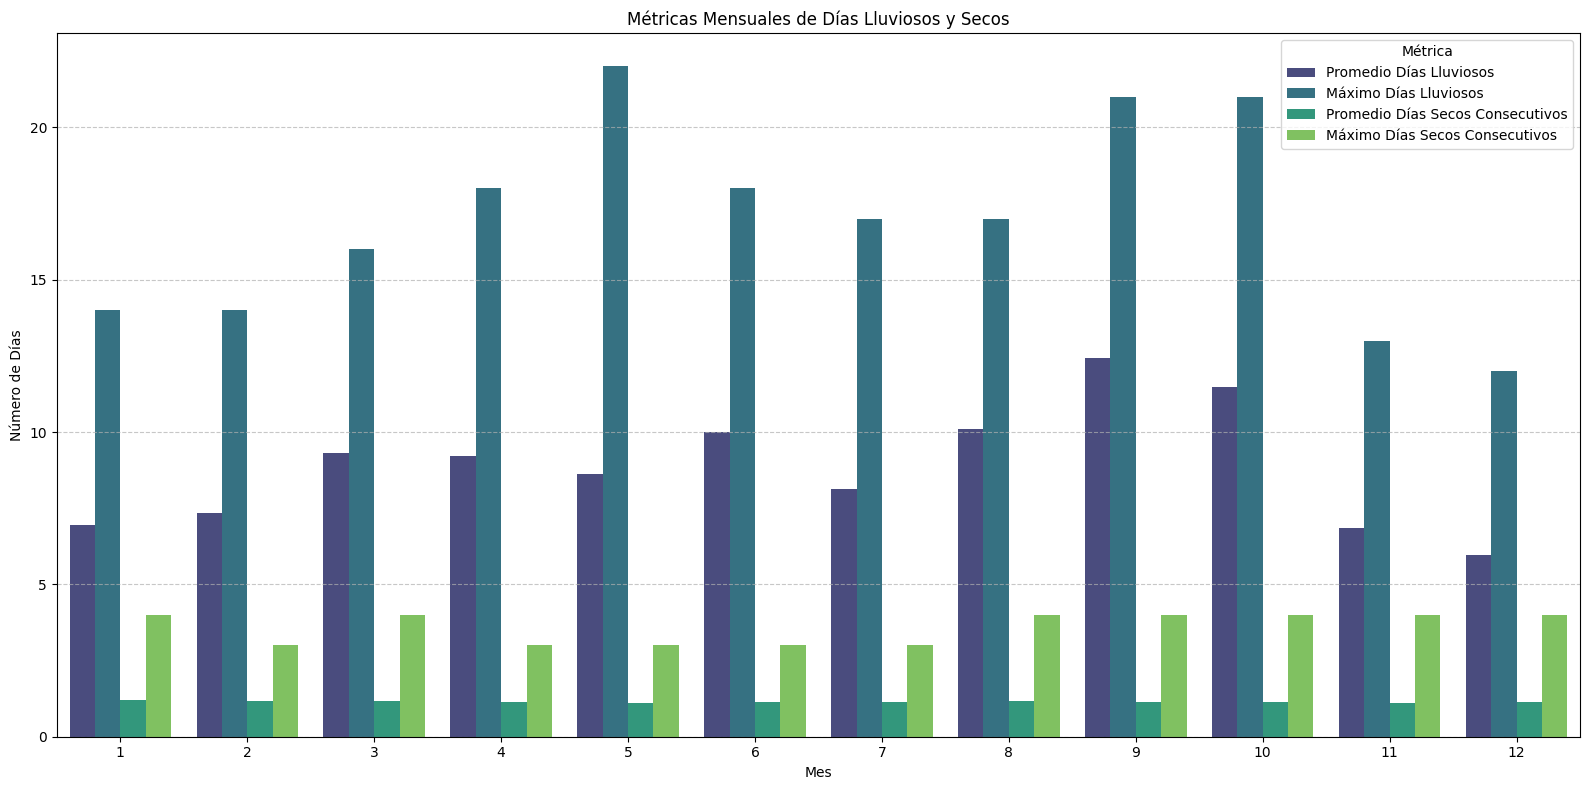

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Promedio de días lluviosos por mes (total rainy days in a month, averaged over years)
#    `dias_lluvia` already contains the mean of `is_rainy` (total rainy days) per month across all years.
monthly_avg_rainy_days = dias_lluvia.rename(columns={'is_rainy': 'Promedio Días Lluviosos'})

# 2. Máximo de días lluviosos por mes (maximum total rainy days in any given month across all years)
#    `df_dias` has 'year', 'month', 'is_rainy' (sum of rainy days for that year/month)
monthly_max_rainy_days = df_dias.groupby('month')['is_rainy'].max().reset_index()
monthly_max_rainy_days.rename(columns={'is_rainy': 'Máximo Días Lluviosos'}, inplace=True)

# 3. Promedio de días secos (consecutivos) por mes
#    `monthly_consecutive_dry_stats` has 'year', 'month', 'mean' (avg consecutive dry days for that year/month)
#    We need the average of these 'mean' values across all years for each month.
monthly_avg_dry_consecutive_days = monthly_consecutive_dry_stats.groupby('month')['mean'].mean().reset_index()
monthly_avg_dry_consecutive_days.rename(columns={'mean': 'Promedio Días Secos Consecutivos'}, inplace=True)

# 4. Máximo de días secos (consecutivos) por mes
#    `monthly_consecutive_dry_stats` has 'year', 'month', 'max' (max consecutive dry days for that year/month)
#    We need the maximum of these 'max' values across all years for each month.
monthly_max_dry_consecutive_days = monthly_consecutive_dry_stats.groupby('month')['max'].max().reset_index()
monthly_max_dry_consecutive_days.rename(columns={'max': 'Máximo Días Secos Consecutivos'}, inplace=True)

# Combinar todos los DataFrames
monthly_metrics = monthly_avg_rainy_days.merge(monthly_max_rainy_days, on='month')
monthly_metrics = monthly_metrics.merge(monthly_avg_dry_consecutive_days, on='month')
monthly_metrics = monthly_metrics.merge(monthly_max_dry_consecutive_days, on='month')

# Reestructurar el DataFrame para plotting con seaborn.barplot
monthly_metrics_melted = monthly_metrics.melt(id_vars='month', var_name='Métrica', value_name='Valor')

# Crear la gráfica de barras
plt.figure(figsize=(16, 8))
sns.barplot(x='month', y='Valor', hue='Métrica', data=monthly_metrics_melted, palette='viridis')
plt.title('Métricas Mensuales de Días Lluviosos y Secos')
plt.xlabel('Mes')
plt.ylabel('Número de Días')
plt.xticks(rotation=0)
plt.legend(title='Métrica')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Filtrar solo los días con precipitación para calcular los percentiles,
# ya que los días con 2mm o mas no son de interés para "lluvias críticas"
precip_only = df[df['lluvia_mm'] > 2]['lluvia_mm']

# Calcular los percentiles para definir umbrales de lluvia crítica
percentiles = [
    0.90, # 90th percentile
    0.95, # 95th percentile
    0.99  # 99th percentile
]

umbrales_criticos = precip_only.quantile(percentiles)

print("\nUmbrales de Precipitación Diaria Crítica (en mm):")
display(umbrales_criticos)

# También podemos calcular el número de eventos que superan cada umbral

# Contar días que superan el percentil 90
num_eventos_p90 = df[df['lluvia_mm'] > umbrales_criticos[0.90]].shape[0]

# Contar días que superan el percentil 95
num_eventos_p95 = df[df['lluvia_mm'] > umbrales_criticos[0.95]].shape[0]

# Contar días que superan el percentil 99
num_eventos_p99 = df[df['lluvia_mm'] > umbrales_criticos[0.99]].shape[0]

print(f"\nNúmero de días con precipitación superior al P90 ({umbrales_criticos[0.90]:.2f} mm): {num_eventos_p90} días")
print(f"Número de días con precipitación superior al P95 ({umbrales_criticos[0.95]:.2f} mm): {num_eventos_p95} días")
print(f"Número de días con precipitación superior al P99 ({umbrales_criticos[0.99]:.2f} mm): {num_eventos_p99} días")


Umbrales de Precipitación Diaria Crítica (en mm):


,lluvia_mm
0.90,33.244505
0.95,49.094341
0.99,91.281703



Número de días con precipitación superior al P90 (33.24 mm): 420 días
Número de días con precipitación superior al P95 (49.09 mm): 210 días
Número de días con precipitación superior al P99 (91.28 mm): 42 días


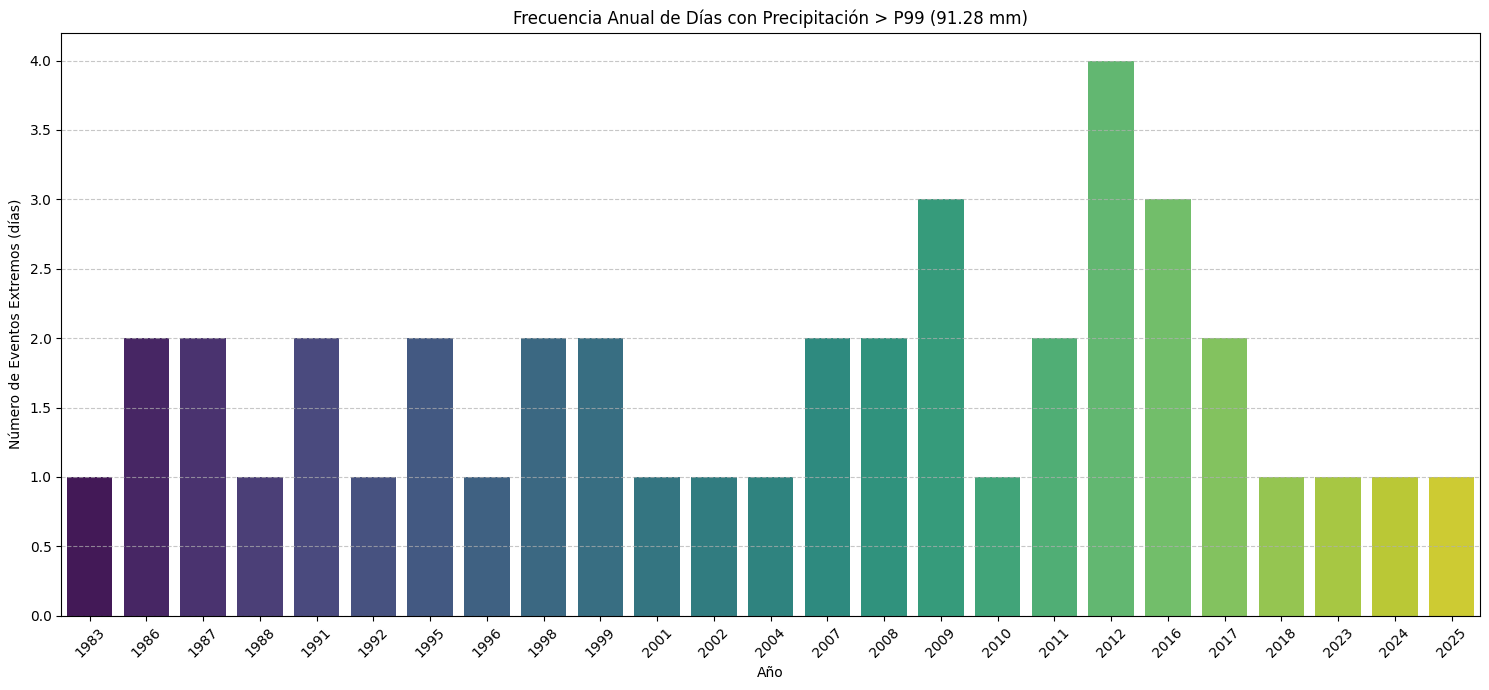

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener el umbral P99
umbral_p99 = umbrales_criticos[0.99]

# Filtrar el DataFrame para obtener solo los eventos que superan el P99
eventos_p99 = df[df['lluvia_mm'] > umbral_p99].copy()

# Extraer el año de la fecha para agrupar
eventos_p99['year'] = eventos_p99['fecha'].dt.year

# Contar el número de eventos P99 por año
frecuencia_anual_p99 = eventos_p99.groupby('year').size().reset_index(name='count')

# Visualizar la frecuencia anual
fig7 = plt.figure(figsize=(15, 7))
sns.barplot(x='year', y='count', data=frecuencia_anual_p99, palette='viridis')
plt.title(f'Frecuencia Anual de Días con Precipitación > P99 ({umbral_p99:.2f} mm)')
plt.xlabel('Año')
plt.ylabel('Número de Eventos Extremos (días)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calcular la precipitación total anual
total_annual_precipitation_df = df.groupby('year')['lluvia_mm'].sum().reset_index()
total_annual_precipitation_df.rename(columns={'lluvia_mm': 'total_annual_precipitation'}, inplace=True)

# Calcular los percentiles 33 y 67 de la precipitación anual
lower_threshold = total_annual_precipitation_df['total_annual_precipitation'].quantile(0.33)
upper_threshold = total_annual_precipitation_df['total_annual_precipitation'].quantile(0.67)

print(f"Umbral de precipitación anual baja (P33): {lower_threshold:.2f} mm")
print(f"Umbral de precipitación anual alta (P67): {upper_threshold:.2f} mm")

# Función para clasificar los años
def classify_precipitation_year(annual_prec):
    if annual_prec <= lower_threshold:
        return 'Baja'
    elif annual_prec >= upper_threshold:
        return 'Alta'
    else:
        return 'Promedio'

# Aplicar la clasificación al DataFrame
total_annual_precipitation_df['precipitation_category'] = total_annual_precipitation_df['total_annual_precipitation'].apply(classify_precipitation_year)

print("\nClasificación de años por nivel de precipitación:")
display(total_annual_precipitation_df.head())
display(total_annual_precipitation_df.tail())

Umbral de precipitación anual baja (P33): 1329.63 mm
Umbral de precipitación anual alta (P67): 1566.16 mm

Clasificación de años por nivel de precipitación:


,year,total_annual_precipitation,precipitation_category
0,1981,1949.868924,Alta
1,1982,1026.520767,Baja
2,1983,1460.637596,Promedio
3,1984,1452.015686,Promedio
4,1985,1579.925854,Alta


,year,total_annual_precipitation,precipitation_category
40,2021,1013.826828,Baja
41,2022,1185.810940,Baja
42,2023,1251.642120,Baja
43,2024,1647.089421,Alta
44,2025,1675.220524,Alta


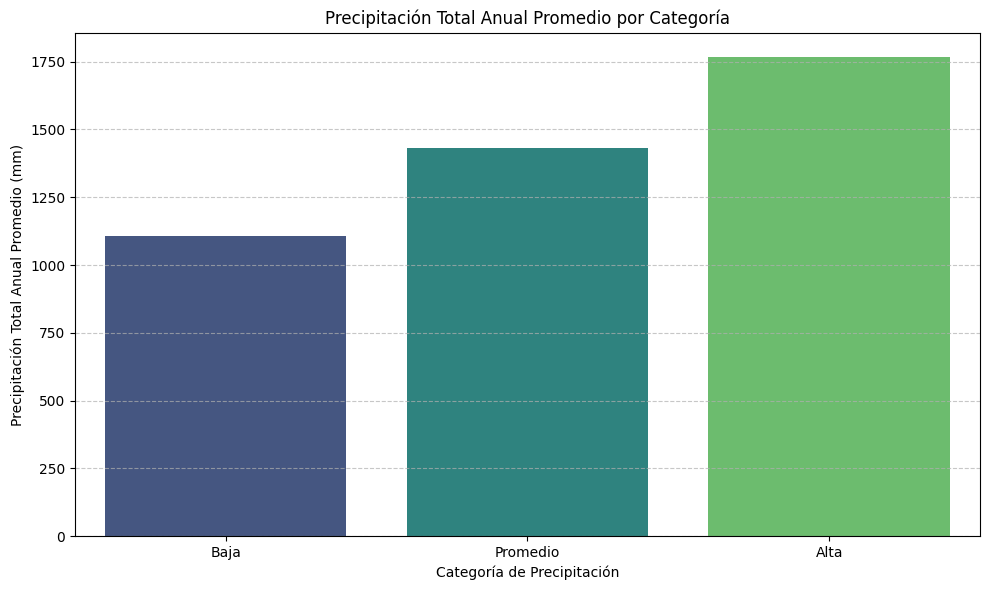

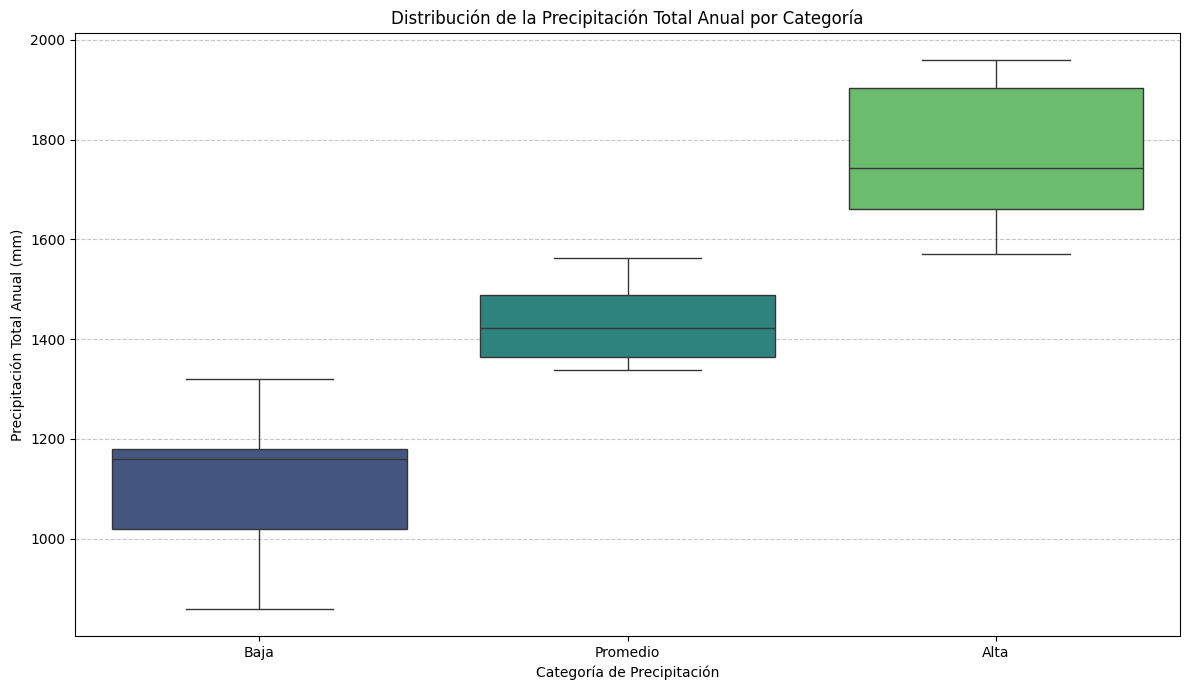

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar las categorías para la visualización
category_order = ['Baja', 'Promedio', 'Alta']

# Calcular el promedio de precipitación por categoría
mean_prec_by_category = total_annual_precipitation_df.groupby('precipitation_category')['total_annual_precipitation'].mean().reindex(category_order).reset_index()

fig_category_bar = plt.figure(figsize=(10, 6))
sns.barplot(x='precipitation_category', y='total_annual_precipitation', data=mean_prec_by_category, palette='viridis', order=category_order)
plt.title('Precipitación Total Anual Promedio por Categoría')
plt.xlabel('Categoría de Precipitación')
plt.ylabel('Precipitación Total Anual Promedio (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualización de la distribución de la precipitación anual por categoría usando un boxplot
fig_category_box = plt.figure(figsize=(12, 7))
sns.boxplot(x='precipitation_category', y='total_annual_precipitation', data=total_annual_precipitation_df, palette='viridis', order=category_order)
plt.title('Distribución de la Precipitación Total Anual por Categoría')
plt.xlabel('Categoría de Precipitación')
plt.ylabel('Precipitación Total Anual (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Cargar el archivo nino.csv
try:
    enso_raw_df = pd.read_csv('/content/nino.csv', encoding='latin1') # Especificar codificación 'latin1'
    print("Datos ENSO cargados correctamente.")
    display(enso_raw_df.head())
    display(enso_raw_df.info())
except FileNotFoundError:
    print("Error: El archivo 'nino.csv' no se encuentra en '/content/nino.csv'.")
    print("Por favor, asegúrate de subir el archivo a la ubicación correcta en Colab.")
    enso_raw_df = pd.DataFrame() # Crear un DataFrame vacío para evitar errores posteriores
except UnicodeDecodeError:
    print("Error de codificación: El archivo no pudo leerse con 'latin1'. Intenta otra codificación si el problema persiste.")
    enso_raw_df = pd.DataFrame() # Crear un DataFrame vacío para evitar errores posteriores

Datos ENSO cargados correctamente.


,Unnamed: 0,Date,Year,Month,Global Temperature Anomaly,Nino 1+2 SST,Nino 1+2 SST Anomaly,Nino 3 SST,Nino 3 SST Anomaly,Nino 3.4 SST,...,BEST,Season (2-Month),MEI.ext,MEI.v2,Season (3-Month),ONI,RONI,Season (12-Month),ENSO PhaseIntensity (ONI-based),ENSO PhaseIntensity (RONI-based)
0,0,1/1/1950,1950,JAN,-0.26,23.01,-1.55,23.56,-2.10,24.55,...,-0.67,DJ,-0.941,NaN,DJF,-1.53,-1.58,1950-1951,N,N
1,1,2/1/1950,1950,FEB,-0.27,24.32,-1.78,24.89,-1.52,25.06,...,-1.52,JF,-1.131,NaN,JFM,-1.34,-1.26,1950-1951,N,N
2,2,3/1/1950,1950,MAR,-0.07,25.11,-1.38,26.36,-0.84,25.87,...,-1.37,FM,-1.347,NaN,FMA,-1.16,-0.96,1950-1951,N,N
3,3,4/1/1950,1950,APR,-0.21,23.63,-1.90,26.44,-1.14,26.28,...,-1.31,MA,-1.377,NaN,MAM,-1.18,-1.10,1950-1951,N,N
4,4,5/1/1950,1950,MAY,-0.11,22.68,-1.74,25.69,-1.57,26.18,...,-1.26,AM,-1.282,NaN,AMJ,-1.07,-1.20,1950-1951,N,N


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         924 non-null    int64  
 1   Date                               924 non-null    object 
 2   Year                               924 non-null    int64  
 3   Month                              924 non-null    object 
 4   Global Temperature Anomaly         917 non-null    float64
 5   Nino 1+2 SST                       917 non-null    float64
 6   Nino 1+2 SST Anomaly               917 non-null    float64
 7   Nino 3 SST                         917 non-null    float64
 8   Nino 3 SST Anomaly                 917 non-null    float64
 9   Nino 3.4 SST                       917 non-null    float64
 10  Nino 3.4 SST Anomaly               917 non-null    float64
 11  Nino 4 SST                         917 non-null    float64

None

In [ ]:
if not enso_raw_df.empty:
    # Calcular el promedio anual del índice Nino3.4_Anom (corregido a 'Nino 3.4 SST Anomaly')
    annual_enso = enso_raw_df.groupby('Year')['Nino 3.4 SST Anomaly'].mean().reset_index()
    annual_enso.columns = ['year', 'avg_nino34_anom']

    # Función para clasificar los años en fases ENSO
    def classify_enso_year(anom):
        if anom >= 0.5:
            return 'El Niño'
        elif anom <= -0.5:
            return 'La Niña'
        else:
            return 'Neutral'

    # Aplicar la clasificación
    annual_enso['enso_phase'] = annual_enso['avg_nino34_anom'].apply(classify_enso_year)
    enso_df_for_merge = annual_enso[['year', 'enso_phase']]

    print("Clasificación anual de fases ENSO:")
    display(enso_df_for_merge.head())

    # Fusionar con el DataFrame de precipitación anual
    # total_annual_precipitation_df ya está disponible del análisis anterior
    df_enso_merged = pd.merge(total_annual_precipitation_df, enso_df_for_merge, on='year', how='left')

    print("\nDataFrame de precipitación anual fusionado con fases ENSO:")
    display(df_enso_merged.head())
    display(df_enso_merged.info())

    # Verificar si hay años en el df de precipitación sin datos ENSO
    if df_enso_merged['enso_phase'].isnull().any():
        print("\nAdvertencia: Algunos años en el DataFrame de precipitación no tienen datos ENSO de la fuente proporcionada. Se rellenarán como 'No Disponible'.")
        df_enso_merged['enso_phase'].fillna('No Disponible', inplace=True)
        print("Años sin datos ENSO:\n", df_enso_merged[df_enso_merged['enso_phase'] == 'No Disponible']['year'].unique())

else:
    print("No se pudo cargar el archivo ENSO, saltando el procesamiento y la fusión.")
    df_enso_merged = pd.DataFrame() # Asegurar que df_enso_merged exista aunque vacío

Clasificación anual de fases ENSO:


,year,enso_phase
0,1950,La Niña
1,1951,Neutral
2,1952,Neutral
3,1953,Neutral
4,1954,La Niña



DataFrame de precipitación anual fusionado con fases ENSO:


,year,total_annual_precipitation,precipitation_category,enso_phase
0,1981,1949.868924,Alta,Neutral
1,1982,1026.520767,Baja,El Niño
2,1983,1460.637596,Promedio,Neutral
3,1984,1452.015686,Promedio,La Niña
4,1985,1579.925854,Alta,La Niña


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        45 non-null     int32  
 1   total_annual_precipitation  45 non-null     float64
 2   precipitation_category      45 non-null     object 
 3   enso_phase                  45 non-null     object 
dtypes: float64(1), int32(1), object(2)
memory usage: 1.4+ KB


None

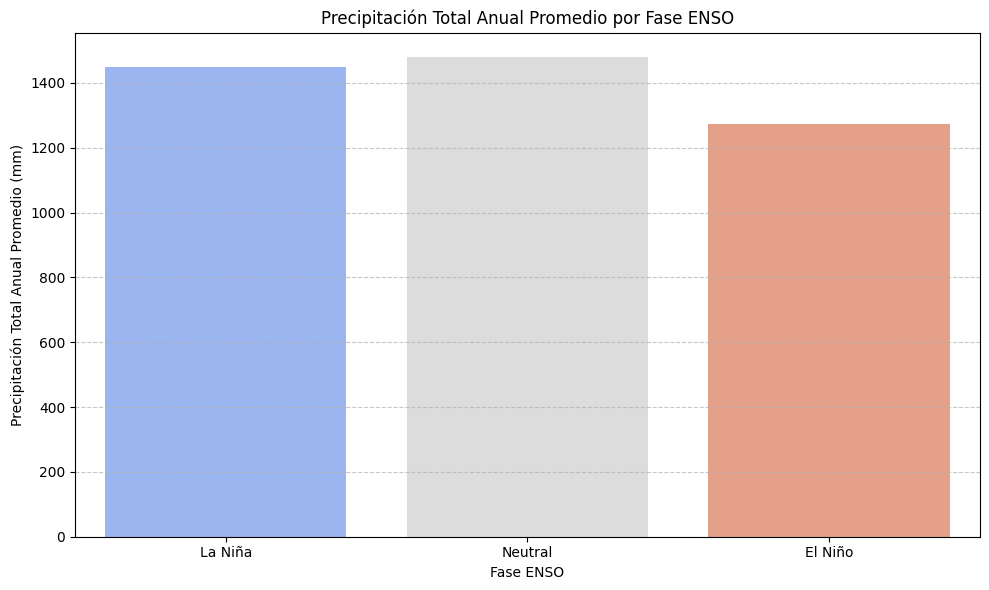

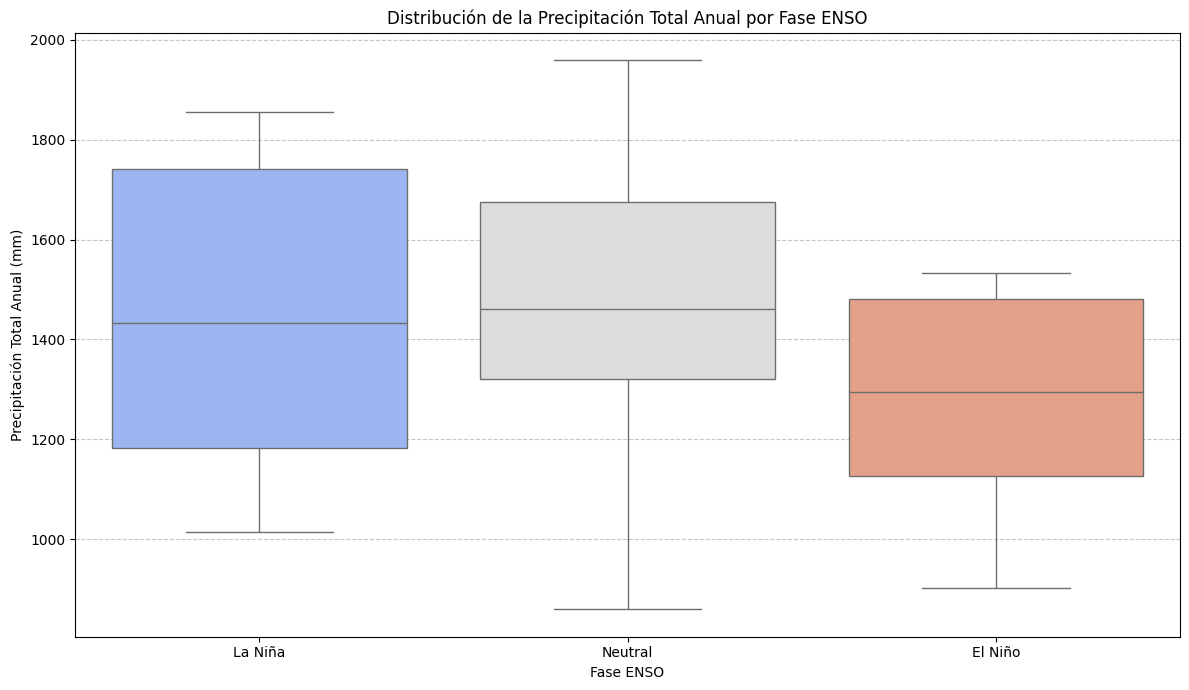

In [ ]:
if not df_enso_merged.empty:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Ordenar las categorías para la visualización
    enso_order = ['La Niña', 'Neutral', 'El Niño', 'No Disponible'] # Incluir 'No Disponible' si aplica
    enso_order = [phase for phase in enso_order if phase in df_enso_merged['enso_phase'].unique()] # Solo incluir las fases presentes

    # Calcular el promedio de precipitación anual por fase ENSO
    mean_annual_prec_by_enso = df_enso_merged.groupby('enso_phase')['total_annual_precipitation'].mean().reindex(enso_order).reset_index()

    fig_enso_bar = plt.figure(figsize=(10, 6))
    sns.barplot(x='enso_phase', y='total_annual_precipitation', data=mean_annual_prec_by_enso, palette='coolwarm', order=enso_order)
    plt.title('Precipitación Total Anual Promedio por Fase ENSO')
    plt.xlabel('Fase ENSO')
    plt.ylabel('Precipitación Total Anual Promedio (mm)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # También podemos ver la distribución de la precipitación anual total para cada fase ENSO
    fig_enso_box = plt.figure(figsize=(12, 7))
    sns.boxplot(x='enso_phase', y='total_annual_precipitation', data=df_enso_merged, palette='coolwarm', order=enso_order)
    plt.title('Distribución de la Precipitación Total Anual por Fase ENSO')
    plt.xlabel('Fase ENSO')
    plt.ylabel('Precipitación Total Anual (mm)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No se generaron visualizaciones debido a la falta de datos ENSO.")

In [ ]:
import numpy as np
from scipy.stats import gamma, norm

# 1. Calcular la precipitación total mensual
monthly_prec = df.groupby(['year', 'month'])['lluvia_mm'].sum().reset_index()
monthly_prec['date'] = pd.to_datetime(monthly_prec['year'].astype(str) + '-' + monthly_prec['month'].astype(str))
monthly_prec = monthly_prec.sort_values('date').reset_index(drop=True)

# 2. Función para calcular el SPI para una escala de tiempo dada (en este caso, 1 mes)
def calculate_spi(df_monthly_prec, scale=1):
    spi_values = []
    # Iterar por cada mes del año (1 a 12)
    for month_num in range(1, 13):
        # Filtrar los datos de precipitación para el mes actual
        monthly_data = df_monthly_prec[df_monthly_prec['month'] == month_num]['lluvia_mm']

        # Si no hay datos para el mes, continuar
        if monthly_data.empty or (monthly_data == 0).all():
            spi_values.extend([np.nan] * len(df_monthly_prec[df_monthly_prec['month'] == month_num]))
            continue

        # Ajustar la distribución Gamma a los datos de precipitación del mes
        # Eliminar ceros para el ajuste de la distribución Gamma (escala pequeña si hay muchos ceros)
        non_zero_monthly_data = monthly_data[monthly_data > 0]

        # Si después de eliminar ceros no hay datos, o todos eran ceros, asignar NaN
        if non_zero_monthly_data.empty:
            spi_values.extend([np.nan] * len(monthly_data))
            continue

        # Parámetros de la distribución Gamma
        alpha, loc, beta = gamma.fit(non_zero_monthly_data, floc=0) # floc=0 porque la precipitación es >= 0

        # Calcular la probabilidad acumulada (CDF) para cada valor de precipitación del mes
        # Para los ceros, la CDF es 0 (o la proporción de ceros si se usa GEV/mixta)
        cdf_values = []
        for val in monthly_data:
            if val == 0:
                # Manejo de ceros: estimar la probabilidad de cero
                prob_zero = (monthly_data == 0).sum() / len(monthly_data)
                cdf_values.append(prob_zero)
            else:
                cdf_values.append(gamma.cdf(val, alpha, loc, beta))

        # Convertir a numpy array
        cdf_values = np.array(cdf_values)

        # Estandarizar a una distribución normal (calcular el valor Z)
        spi_month = norm.ppf(cdf_values) # Percent-point function (inversa de la CDF normal)
        spi_values.extend(spi_month)

    # Añadir los valores SPI al DataFrame original y ordenar por fecha
    df_monthly_prec_spi = df_monthly_prec.copy()
    df_monthly_prec_spi = df_monthly_prec_spi.sort_values('date') # Asegurar el orden para la asignación
    df_monthly_prec_spi['spi'] = spi_values
    return df_monthly_prec_spi

# Calcular el SPI a 1 mes
spi_1month_df = calculate_spi(monthly_prec, scale=1)

print("Primeros registros del DataFrame con SPI a 1 mes:")
display(spi_1month_df.head())
display(spi_1month_df.tail())

# Obtener estadísticas básicas del SPI
print("\nEstadísticas del SPI a 1 mes:")
display(spi_1month_df['spi'].describe())

Primeros registros del DataFrame con SPI a 1 mes:


,year,month,lluvia_mm,date,spi
0,1981,1,56.776299,1981-01-01,0.892537
1,1981,2,44.033858,1981-02-01,0.424753
2,1981,3,69.126139,1981-03-01,0.205219
3,1981,4,46.527048,1981-04-01,0.675161
4,1981,5,312.899161,1981-05-01,-0.452483


,year,month,lluvia_mm,date,spi
535,2025,8,150.631249,2025-08-01,-0.692936
536,2025,9,246.082248,2025-09-01,-1.300090
537,2025,10,528.079329,2025-10-01,0.447003
538,2025,11,142.698936,2025-11-01,1.570467
539,2025,12,21.046657,2025-12-01,-1.273309



Estadísticas del SPI a 1 mes:


,spi
count,540.000000
mean,-0.002744
std,1.000352
min,-2.375902
25%,-0.737117
50%,-0.080280
75%,0.676644
max,4.246551


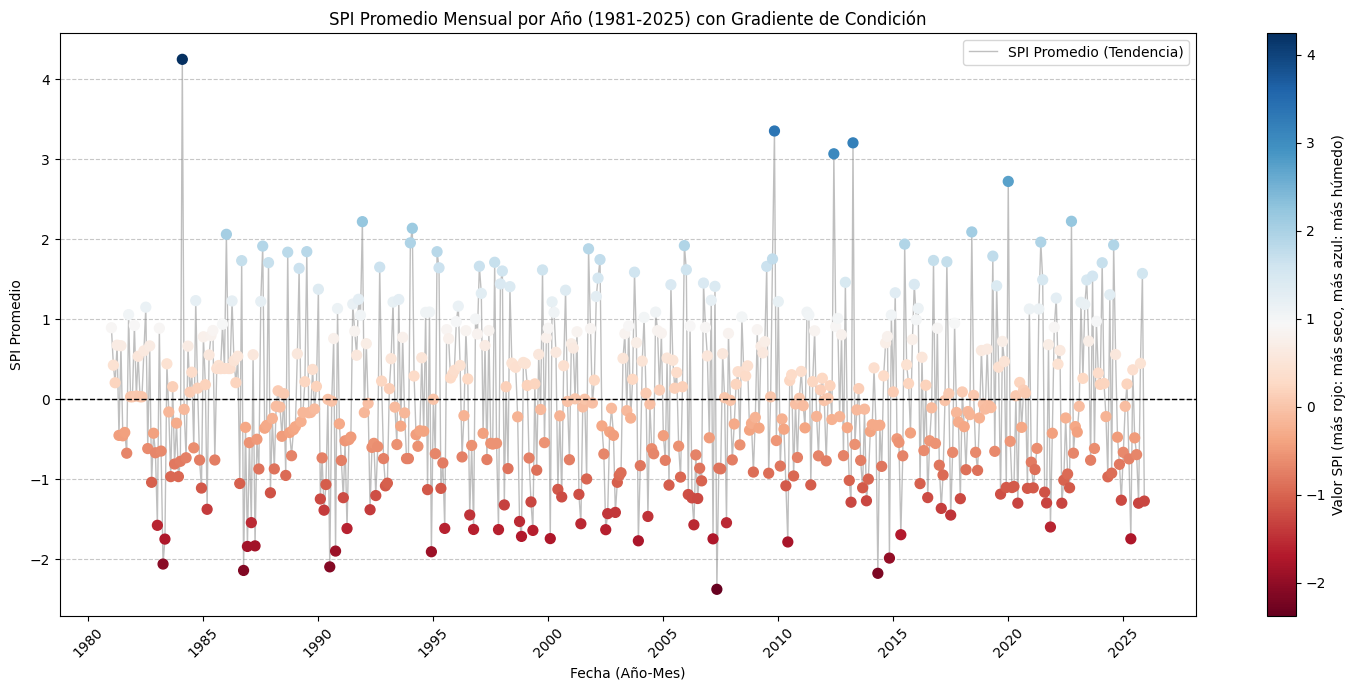

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the average SPI per year and month
# Create a 'year_month' column for better plotting
spi_1month_df['year_month'] = pd.to_datetime(spi_1month_df['year'].astype(str) + '-' + spi_1month_df['month'].astype(str) + '-01')
monthly_avg_spi_year_month = spi_1month_df.groupby('year_month')['spi'].mean().reset_index()

# Plot the average SPI per year-month as a line chart
plt.figure(figsize=(15, 7))

# Use a scatter plot with color mapping to represent drier/wetter conditions
# and overlay it on a transparent line plot for the overall trend
sns.lineplot(x='year_month', y='spi', data=monthly_avg_spi_year_month, color='gray', alpha=0.5, linewidth=1, label='SPI Promedio (Tendencia)')

# Add scatter points colored by SPI value
scatter = plt.scatter(monthly_avg_spi_year_month['year_month'], monthly_avg_spi_year_month['spi'],
                      c=monthly_avg_spi_year_month['spi'], cmap='RdBu', s=50, zorder=2) # Changed to 'RdBu' for red=dry, blue=wet

plt.title('SPI Promedio Mensual por Año (1981-2025) con Gradiente de Condición')
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('SPI Promedio')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1) # Línea de referencia para condiciones normales
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Valor SPI (más rojo: más seco, más azul: más húmedo)')

plt.tight_layout()
plt.show()